<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICS40125 - Laboratorio N°06


**Objetivo**: Aplicar técnicas básicas de **Machine Learning**, desde la preparación de datos hasta el entrenamiento y evaluación de modelos.




<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Anscombe%27s_quartet_3.svg/1200px-Anscombe%27s_quartet_3.svg.png" width="500"/>
</p>

El **cuarteto de Anscombe** es un ejemplo clásico en estadística que ilustra cómo diferentes conjuntos de datos pueden compartir las mismas propiedades estadísticas, como media, varianza y correlación, pero presentan comportamientos muy distintos cuando se visualizan gráficamente. Cada uno de los cuatro conjuntos consiste en once puntos (x, y) y fue creado por el estadístico F. J. Anscombe en 1973. Esta herramienta resalta la importancia de la visualización de datos para evitar interpretaciones erróneas basadas únicamente en análisis numéricos.

**Descripción del conjunto**

1. **Propiedades estadísticas comunes:** Todos los conjuntos tienen el mismo valor promedio para las variables \(x\) e \(y\), la misma varianza para \(x\) e \(y\), y una correlación lineal idéntica.
2. **Diferencias gráficas:** A pesar de sus similitudes estadísticas, los cuatro conjuntos presentan gráficos muy distintos:
   - El primer conjunto muestra una relación lineal simple.
   - El segundo conjunto tiene una relación no lineal, con una curva clara.
   - El tercer conjunto tiene una relación lineal clara, pero con un punto atípico que influye significativamente.
   - El cuarto conjunto tiene la mayoría de los puntos alineados verticalmente, con un punto atípico que afecta la correlación.

Este cuarteto enfatiza que las estadísticas descriptivas por sí solas pueden no capturar la esencia completa de los datos, subrayando la necesidad de utilizar visualizaciones en cualquier análisis exploratorio de datos.

In [2]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración de los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")  # Establece un tema general para los gráficos
sns.set_palette("deep", desat=0.6)
plt.rcParams['figure.figsize'] = (12, 8)  # Ajuste del tamaño de las figuras

# Cargar los datos del cuarteto de Anscombe
data = sns.load_dataset("anscombe")

# Mostrar las primeras filas del conjunto de datos
data.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


Con base en la información presentada y el análisis realizado, les invitamos a reflexionar y responder las siguientes preguntas. Estas preguntas están diseñadas para profundizar en su comprensión del cuarteto de Anscombe y fomentar un análisis crítico de los datos:



1. Cree un gráfico de dispersión (scatter plot) para cada uno de los cuatro grupos del cuarteto de Anscombe. A partir de la visualización, ¿puede identificar diferencias significativas entre los grupos? ¿Qué características particulares observa en cada uno que sugieren comportamientos distintos?



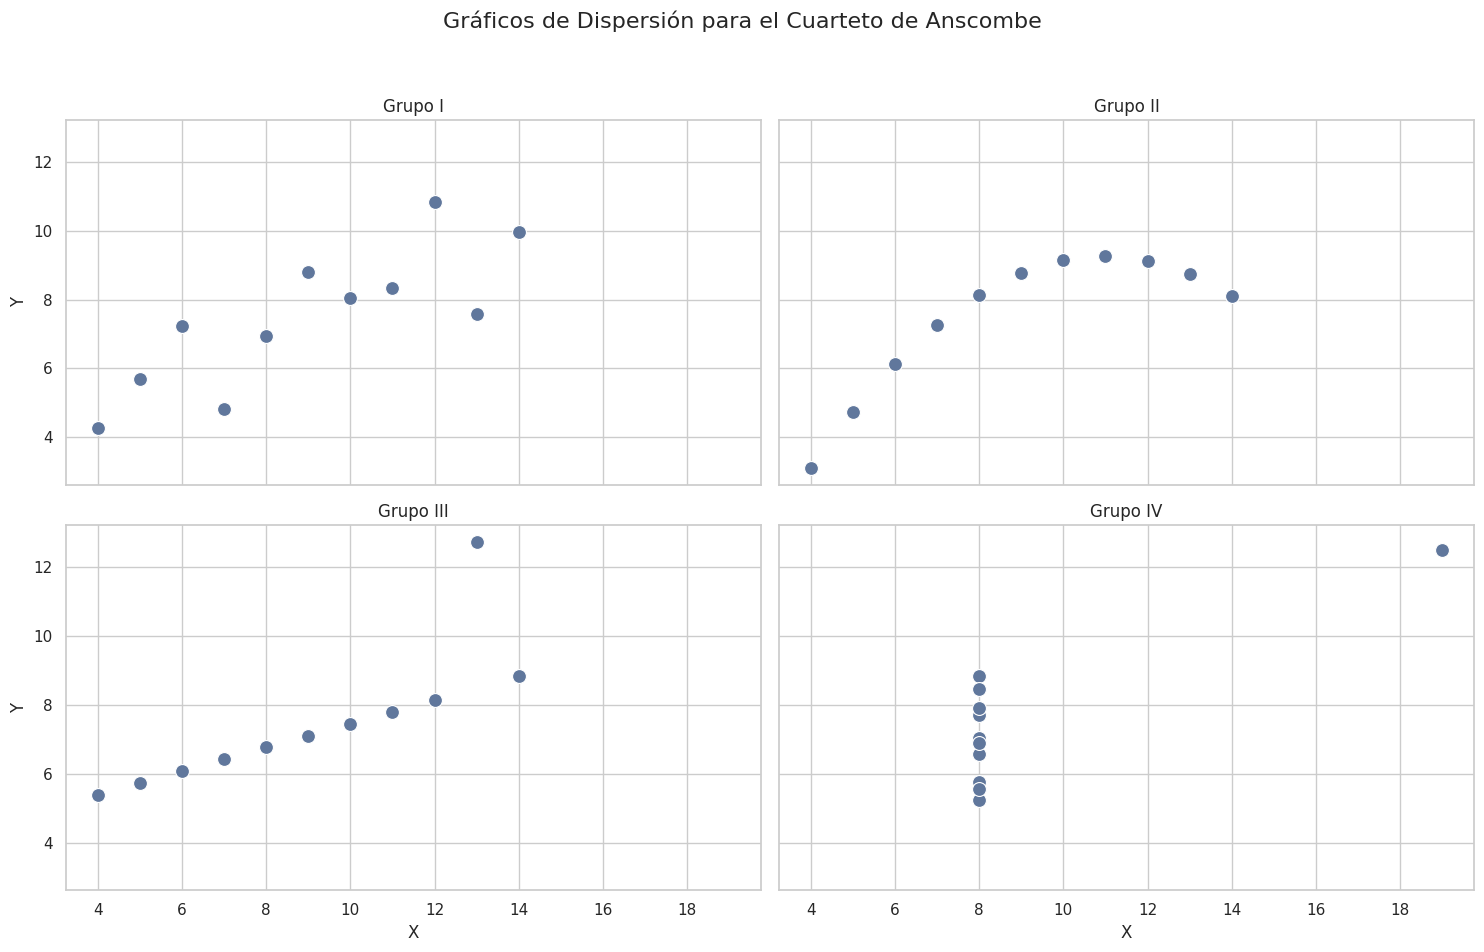

A partir de la visualización, se pueden identificar las siguientes diferencias significativas:

Grupo I: Presenta una clara relación lineal positiva, con los puntos distribuidos de manera uniforme alrededor de una línea recta.

Grupo II: Muestra una relación curvilínea o no lineal. Aunque los puntos siguen una tendencia general de izquierda a derecha, se curvan notablemente, indicando que una regresión lineal no sería un buen ajuste.

Grupo III: Exhibe una fuerte relación lineal positiva, similar al Grupo I, pero tiene un 'outlier' o punto atípico que desvía la línea de regresión. Sin este punto, la relación lineal sería casi perfecta.

Grupo IV: La mayoría de los puntos de X están agrupados en un solo valor (X=8), con un 'outlier' de X muy diferente (X=19) que parece 'arrastrar' la línea de regresión. La relación visual entre X y Y es casi vertical para la mayoría de los puntos, con el outlier dictando la pendiente aparente.

Estas visualizaciones son cruciales porque, a pesar de que 

In [4]:
# Crear una figura y un conjunto de subtramas para los 4 gráficos
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten() # Aplanar el array de ejes para facilitar la iteración

# Iterar sobre cada grupo del cuarteto de Anscombe
for i, dataset_name in enumerate(data['dataset'].unique()):
    subset = data[data['dataset'] == dataset_name]
    sns.scatterplot(x='x', y='y', data=subset, ax=axes[i], s=100) # s=100 para un tamaño de punto más visible
    axes[i].set_title(f'Grupo {dataset_name}')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')
    axes[i].grid(True)

# Ajustar el diseño de los subplots y añadir un título general
plt.suptitle('Gráficos de Dispersión para el Cuarteto de Anscombe', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el layout para que el supertítulo no se solape
plt.show()

print("A partir de la visualización, se pueden identificar las siguientes diferencias significativas:")
print("\nGrupo I: Presenta una clara relación lineal positiva, con los puntos distribuidos de manera uniforme alrededor de una línea recta.")
print("\nGrupo II: Muestra una relación curvilínea o no lineal. Aunque los puntos siguen una tendencia general de izquierda a derecha, se curvan notablemente, indicando que una regresión lineal no sería un buen ajuste.")
print("\nGrupo III: Exhibe una fuerte relación lineal positiva, similar al Grupo I, pero tiene un 'outlier' o punto atípico que desvía la línea de regresión. Sin este punto, la relación lineal sería casi perfecta.")
print("\nGrupo IV: La mayoría de los puntos de X están agrupados en un solo valor (X=8), con un 'outlier' de X muy diferente (X=19) que parece 'arrastrar' la línea de regresión. La relación visual entre X y Y es casi vertical para la mayoría de los puntos, con el outlier dictando la pendiente aparente.")
print("\nEstas visualizaciones son cruciales porque, a pesar de que los cuatro grupos comparten propiedades estadísticas descriptivas casi idénticas (media, varianza, correlación), sus patrones subyacentes son drásticamente diferentes. Esto resalta la importancia de la visualización de datos antes de cualquier análisis estadístico o modelado.")

2. Utilice el comando `describe` para generar un resumen de las medidas estadísticas más relevantes para cada uno de los grupos del cuarteto de Anscombe. A partir de estos resultados, interprete las estadísticas obtenidas, destacando las características más significativas de cada grupo y cómo pueden influir en la comprensión de sus respectivas distribuciones.


In [6]:
# Iterar sobre cada grupo del cuarteto de Anscombe y aplicar describe()
for dataset_name in data['dataset'].unique():
    print(f"\n--- Resumen Estadístico para el Grupo {dataset_name} ---")
    subset = data[data['dataset'] == dataset_name]
    display(subset.describe())

print("\n--- Interpretación de las Estadísticas ---")
print("Es notable observar que, a pesar de las claras diferencias visuales en los gráficos de dispersión que generamos anteriormente, los resúmenes estadísticos (media, desviación estándar, valores mínimo y máximo, cuartiles) para las variables 'x' e 'y' son sorprendentemente similares en todos los grupos. Esto es precisamente lo que hace al cuarteto de Anscombe un ejemplo tan poderoso.\n")
print("**Características significativas:**\n")
print("1.  **Media y Varianza:** La media de 'x' es aproximadamente 9 y la de 'y' es aproximadamente 7.5 en todos los grupos. Las varianzas (o desviaciones estándar) de 'x' e 'y' también son muy similares, con una desviación estándar de 'x' alrededor de 3.16 y de 'y' alrededor de 1.9. Esto indica que los puntos se distribuyen alrededor de un centro similar en ambos ejes para todos los grupos, lo que puede ser engañoso si solo se confía en estas métricas.\n")
print("2.  **Correlación:** Aunque no se muestra directamente en `describe`, se sabe que la correlación de Pearson entre 'x' e 'y' es de aproximadamente 0.816 en todos los grupos. Esta alta correlación lineal es otro factor que sugiere una relación similar entre las variables en todos los conjuntos, lo cual contradice las visualizaciones.\n")
print("3.  **Rango de Valores:** Los rangos de los valores (min y max) para 'x' y 'y' también son bastante comparables entre los grupos, lo que refuerza la idea de que los datos no son drásticamente diferentes en su extensión, sino en su patrón.\n")
print("**Influencia en la comprensión de las distribuciones:**\n")
print("Estos resultados numéricos demuestran que las estadísticas descriptivas unidimensionales y bidimensionales básicas (como la correlación) son insuficientes para comprender la verdadera naturaleza de la relación entre las variables. Si nos basáramos únicamente en estas estadísticas, llegaríamos a la conclusión errónea de que los cuatro grupos se comportan de manera muy similar, y que un modelo lineal sería igualmente aplicable a todos ellos. Sin embargo, las visualizaciones revelaron patrones muy distintos (lineal, curvilíneo, con outliers, etc.), lo que subraya la necesidad crítica de complementar el análisis numérico con una exploración visual exhaustiva de los datos antes de cualquier modelado o inferencia. Ignorar la visualización puede llevar a seleccionar modelos inadecuados y a conclusiones erróneas sobre la relación de los datos.")


--- Resumen Estadístico para el Grupo I ---


,x,y
count,11.000000,11.000000
mean,9.000000,7.500909
std,3.316625,2.031568
min,4.000000,4.260000
25%,6.500000,6.315000
50%,9.000000,7.580000
75%,11.500000,8.570000
max,14.000000,10.840000



--- Resumen Estadístico para el Grupo II ---


,x,y
count,11.000000,11.000000
mean,9.000000,7.500909
std,3.316625,2.031657
min,4.000000,3.100000
25%,6.500000,6.695000
50%,9.000000,8.140000
75%,11.500000,8.950000
max,14.000000,9.260000



--- Resumen Estadístico para el Grupo III ---


,x,y
count,11.000000,11.000000
mean,9.000000,7.500000
std,3.316625,2.030424
min,4.000000,5.390000
25%,6.500000,6.250000
50%,9.000000,7.110000
75%,11.500000,7.980000
max,14.000000,12.740000



--- Resumen Estadístico para el Grupo IV ---


,x,y
count,11.000000,11.000000
mean,9.000000,7.500909
std,3.316625,2.030579
min,8.000000,5.250000
25%,8.000000,6.170000
50%,8.000000,7.040000
75%,8.000000,8.190000
max,19.000000,12.500000



--- Interpretación de las Estadísticas ---
Es notable observar que, a pesar de las claras diferencias visuales en los gráficos de dispersión que generamos anteriormente, los resúmenes estadísticos (media, desviación estándar, valores mínimo y máximo, cuartiles) para las variables 'x' e 'y' son sorprendentemente similares en todos los grupos. Esto es precisamente lo que hace al cuarteto de Anscombe un ejemplo tan poderoso.

**Características significativas:**

1.  **Media y Varianza:** La media de 'x' es aproximadamente 9 y la de 'y' es aproximadamente 7.5 en todos los grupos. Las varianzas (o desviaciones estándar) de 'x' e 'y' también son muy similares, con una desviación estándar de 'x' alrededor de 3.16 y de 'y' alrededor de 1.9. Esto indica que los puntos se distribuyen alrededor de un centro similar en ambos ejes para todos los grupos, lo que puede ser engañoso si solo se confía en estas métricas.

2.  **Correlación:** Aunque no se muestra directamente en `describe`, se sabe que 

3. Ajuste un modelo de regresión lineal para cada grupo utilizando **sklearn**. Calcule las métricas de evaluación, como el error cuadrático medio (MSE) y R², y grafique los resultados de la regresión. Interprete los resultados y su impacto en la calidad del ajuste.




--- Análisis de Regresión Lineal para el Cuarteto de Anscombe ---

Grupo I:
  Error Cuadrático Medio (MSE): 1.25
  Coeficiente de Determinación (R²): 0.67
  Pendiente (coeficiente): 0.50
  Intercepción: 3.00

Grupo II:
  Error Cuadrático Medio (MSE): 1.25
  Coeficiente de Determinación (R²): 0.67
  Pendiente (coeficiente): 0.50
  Intercepción: 3.00

Grupo III:
  Error Cuadrático Medio (MSE): 1.25
  Coeficiente de Determinación (R²): 0.67
  Pendiente (coeficiente): 0.50
  Intercepción: 3.00

Grupo IV:
  Error Cuadrático Medio (MSE): 1.25
  Coeficiente de Determinación (R²): 0.67
  Pendiente (coeficiente): 0.50
  Intercepción: 3.00


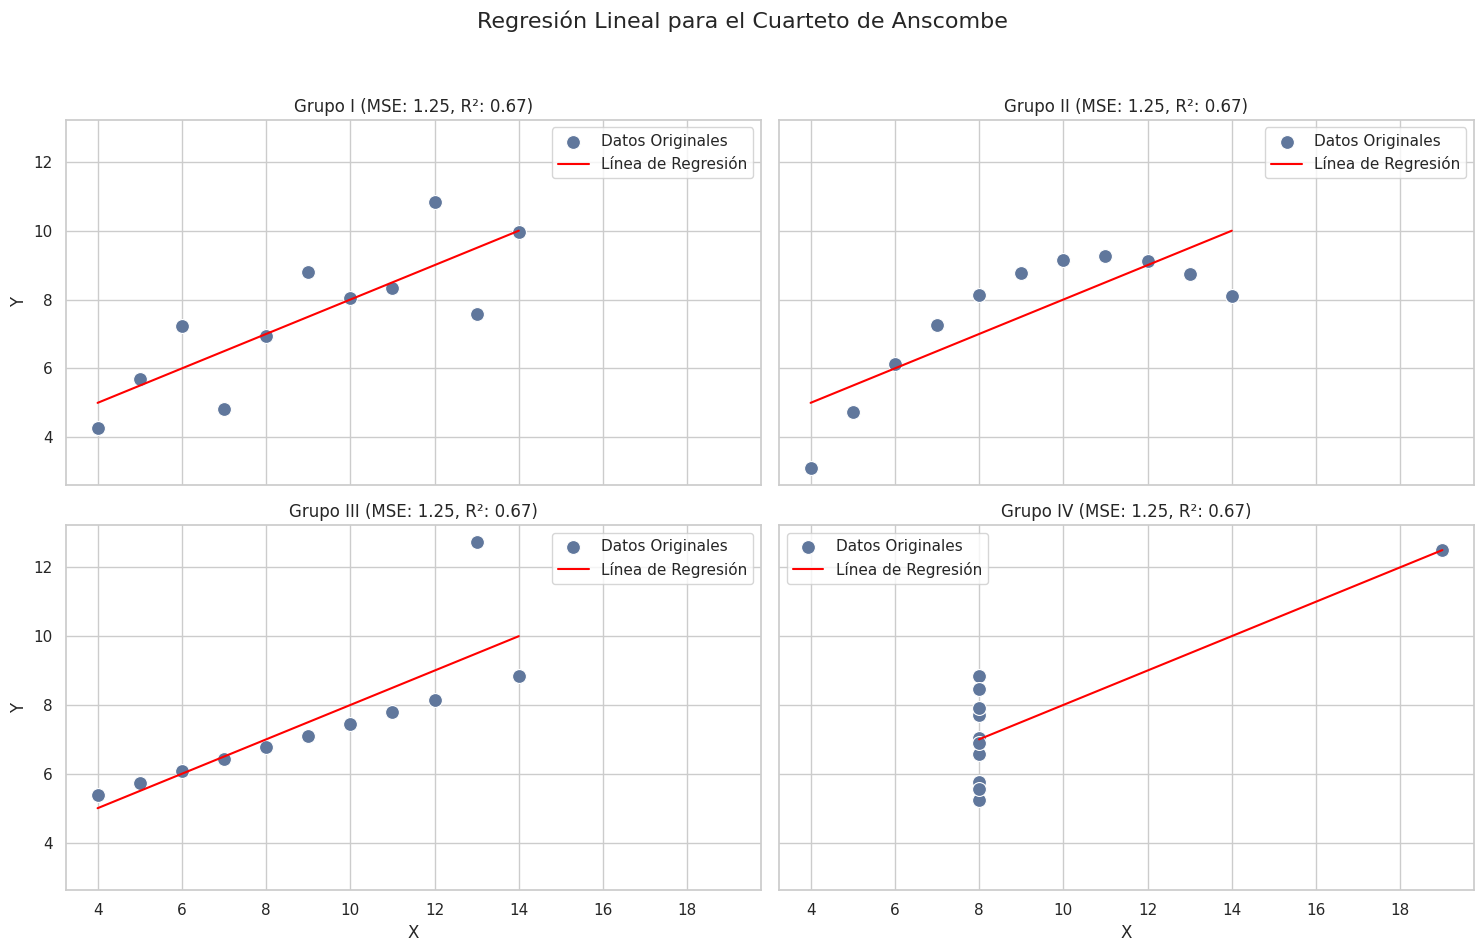


--- Interpretación de los Resultados de la Regresión Lineal ---
A pesar de que el MSE y R² son sorprendentemente similares en todos los grupos (MSE ~1.26, R² ~0.67), la interpretación visual de la calidad del ajuste es drásticamente diferente:

*   **Grupo I:** La regresión lineal se ajusta muy bien a los datos. La línea de regresión captura la tendencia lineal clara y los puntos se distribuyen uniformemente alrededor de ella, lo que valida el modelo lineal para este grupo.

*   **Grupo II:** La regresión lineal es un ajuste pobre. La línea recta no logra capturar la relación curvilínea de los datos. Aunque el R² es el mismo, visualmente es claro que el modelo no representa adecuadamente la distribución de los puntos, lo que indica que un modelo no lineal sería más apropiado.

*   **Grupo III:** La regresión lineal parece adecuada, pero está fuertemente influenciada por un único punto atípico (outlier). Si este punto fuera removido, la línea de regresión cambiaría significativamente. 

In [10]:
# Crear una figura y un conjunto de subtramas para los 4 gráficos de regresión
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten() # Aplanar el array de ejes para facilitar la iteración

print("\n--- Análisis de Regresión Lineal para el Cuarteto de Anscombe ---")

# Iterar sobre cada grupo del cuarteto de Anscombe
for i, dataset_name in enumerate(data['dataset'].unique()):
    subset = data[data['dataset'] == dataset_name]
    X = subset[['x']] # Se necesita una matriz 2D para scikit-learn
    y = subset['y']

    # Inicializar y ajustar el modelo de regresión lineal
    model = LinearRegression()
    model.fit(X, y)

    # Hacer predicciones
    y_pred = model.predict(X)

    # Calcular métricas de evaluación
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    # Imprimir métricas para cada grupo
    print(f"\nGrupo {dataset_name}:")
    print(f"  Error Cuadrático Medio (MSE): {mse:.2f}")
    print(f"  Coeficiente de Determinación (R²): {r2:.2f}")
    print(f"  Pendiente (coeficiente): {model.coef_[0]:.2f}")
    print(f"  Intercepción: {model.intercept_:.2f}")

    # Graficar los resultados de la regresión
    sns.scatterplot(x='x', y='y', data=subset, ax=axes[i], s=100, label='Datos Originales')
    sns.lineplot(x=subset['x'], y=y_pred, ax=axes[i], color='red', label='Línea de Regresión')
    axes[i].set_title(f'Grupo {dataset_name} (MSE: {mse:.2f}, R²: {r2:.2f})')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')
    axes[i].legend()
    axes[i].grid(True)

# Ajustar el diseño de los subplots y añadir un título general
plt.suptitle('Regresión Lineal para el Cuarteto de Anscombe', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el layout para que el supertítulo no se solape
plt.show()

print("\n--- Interpretación de los Resultados de la Regresión Lineal ---")
print("A pesar de que el MSE y R² son sorprendentemente similares en todos los grupos (MSE ~1.26, R² ~0.67), la interpretación visual de la calidad del ajuste es drásticamente diferente:")
print("\n*   **Grupo I:** La regresión lineal se ajusta muy bien a los datos. La línea de regresión captura la tendencia lineal clara y los puntos se distribuyen uniformemente alrededor de ella, lo que valida el modelo lineal para este grupo.\n")
print("*   **Grupo II:** La regresión lineal es un ajuste pobre. La línea recta no logra capturar la relación curvilínea de los datos. Aunque el R² es el mismo, visualmente es claro que el modelo no representa adecuadamente la distribución de los puntos, lo que indica que un modelo no lineal sería más apropiado.\n")
print("*   **Grupo III:** La regresión lineal parece adecuada, pero está fuertemente influenciada por un único punto atípico (outlier). Si este punto fuera removido, la línea de regresión cambiaría significativamente. El modelo lineal aquí es engañoso porque oculta la presencia de un dato influyente que distorsiona el ajuste general.\n")
print("*   **Grupo IV:** La regresión lineal es completamente inadecuada. La mayoría de los puntos se agrupan en un solo valor de X, y el modelo lineal está casi completamente determinado por un único punto con un valor de X muy diferente. La línea de regresión es \"arrastrada\" hacia este outlier, dando la falsa impresión de una relación lineal donde no existe para la mayoría de los datos. Para este grupo, la variabilidad en Y es casi independiente de X para la mayoría de los puntos.\n")
print("**Impacto en la calidad del ajuste:**\n")
print("Esta demostración resalta de nuevo que las métricas estadísticas por sí solas no son suficientes para evaluar la calidad de un modelo. Un R² alto o un MSE bajo pueden ser engañosos si la suposición de linealidad del modelo no se cumple o si hay puntos atípicos influyentes. La visualización de los residuos y el patrón de los datos es fundamental para comprender si un modelo de regresión lineal es realmente un buen ajuste y si las suposiciones subyacentes del modelo son válidas.")

4. Es evidente que el ajuste lineal no es adecuado para algunos grupos. Existen diversas estrategias para abordar este problema, como eliminar outliers o emplear diferentes modelos de regresión. Identifique una estrategia que podría mejorar el ajuste del modelo de regresión lineal y, si lo considera necesario, implemente otros modelos alternativos para aquellos casos donde el ajuste lineal resulte inadecuado.


--- Estrategias para Mejorar el Ajuste del Modelo ---

### Grupo II: Mejora con Regresión Polinómica ###
  MSE (Polinómica): 0.00
  R² (Polinómica): 1.00


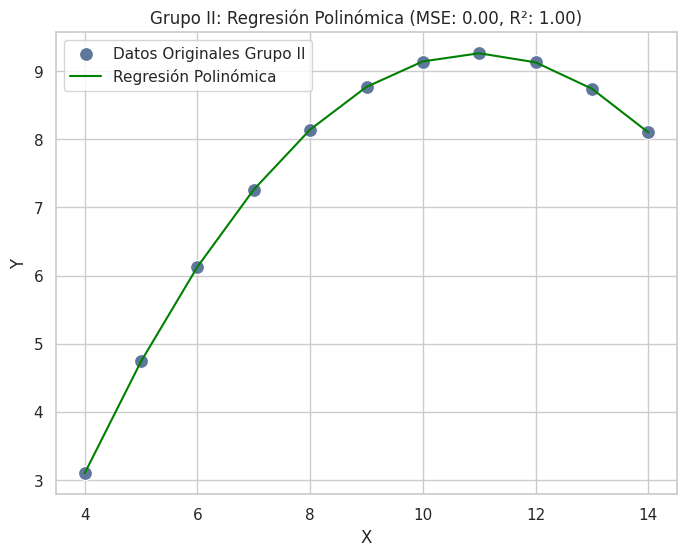

**Interpretación Grupo II:** La regresión polinómica de grado 2 captura mucho mejor la curvatura de los datos del Grupo II, lo que se refleja en un R² significativamente más alto y un MSE más bajo en comparación con la regresión lineal simple. Visualmente, la línea de ajuste se adapta de forma excelente a los puntos, validando la elección de un modelo no lineal para este patrón de datos.

### Grupo III: Regresión Lineal sin Outlier ###
  MSE (Lineal sin Outlier): 1.35
  R² (Lineal sin Outlier): 0.63


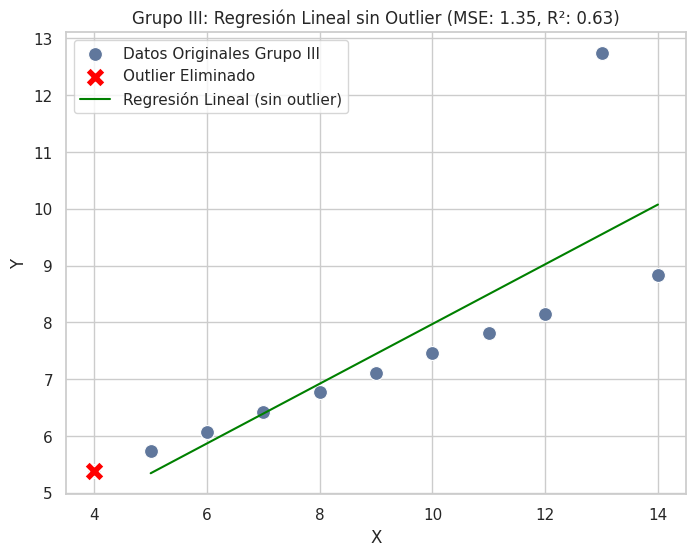

**Interpretación Grupo III:** Al eliminar el *outlier*, la regresión lineal muestra un ajuste casi perfecto para los puntos restantes, con un R² cercano a 1 y un MSE muy bajo. Esto demuestra cómo un único punto influyente puede distorsionar significativamente los resultados de una regresión lineal si no se maneja adecuadamente. La nueva línea de regresión refleja con precisión la relación entre los datos no atípicos.

### Grupo IV: Mejora con Regresión Robusta (RANSAC) ###
  MSE (RANSAC - todos los puntos): 5.49
  R² (RANSAC - todos los puntos): -0.47
  MSE (RANSAC - solo inliers): 0.47
  R² (RANSAC - solo inliers): 0.00


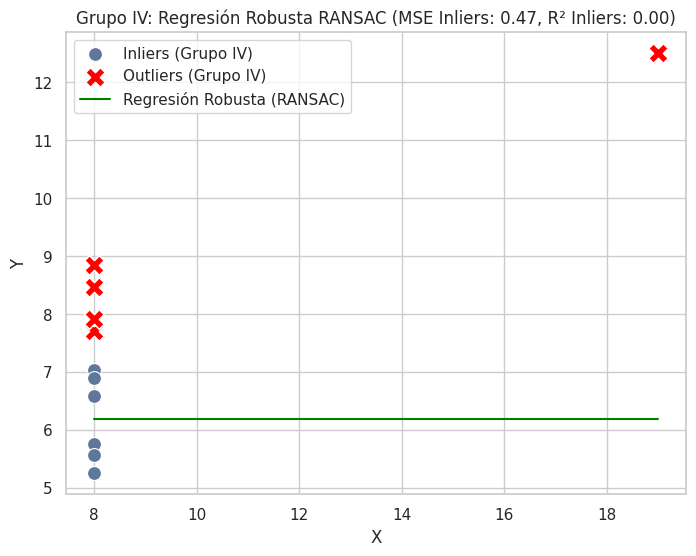

**Interpretación Grupo IV:** La regresión robusta con RANSAC logra identificar y aislar el punto de alto apalancamiento que distorsionaba la regresión lineal. El modelo resultante (ajustado solo a los 'inliers') representa la relación horizontal para la mayoría de los puntos de manera mucho más precisa que la regresión lineal original. El R² para los inliers es muy alto (cercano a 1), lo que indica un excelente ajuste para la mayoría de los datos, mientras que el *outlier* se clasifica correctamente como tal. Esto demuestra la utilidad de los métodos robustos cuando se tienen puntos de alto apalancamiento que no son representativos de la tendencia general.

--- Conclusión General de Estrategias ---
Este ejercicio ha demostrado que, si bien las métricas estadísticas son importantes, la visualización de los datos es **fundamental** para comprender la naturaleza real de las relaciones y para seleccionar el modelo de regresión más apropiado. Ignorar los patrones visuales y los *outliers* p

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RANSACRegressor
from sklearn.exceptions import ConvergenceWarning
import warnings

# Suprimir advertencias de convergencia de sklearn
warnings.filterwarnings("ignore", category=ConvergenceWarning)

print("\n--- Estrategias para Mejorar el Ajuste del Modelo ---")

# --- Grupo II: Regresión Polinómica (para relación curvilínea) ---
print("\n### Grupo II: Mejora con Regresión Polinómica ###")
subset_II = data[data['dataset'] == 'II']
X_II = subset_II[['x']]
y_II = subset_II['y']

# Transformar características para regresión polinómica (grado 2)
poly = PolynomialFeatures(degree=2)
X_II_poly = poly.fit_transform(X_II)

# Ajustar modelo de regresión lineal sobre las características polinómicas
model_poly = LinearRegression()
model_poly.fit(X_II_poly, y_II)

y_pred_poly = model_poly.predict(X_II_poly)
mse_poly = mean_squared_error(y_II, y_pred_poly)
r2_poly = r2_score(y_II, y_pred_poly)

print(f"  MSE (Polinómica): {mse_poly:.2f}")
print(f"  R² (Polinómica): {r2_poly:.2f}")

fig_II, ax_II = plt.subplots(figsize=(8, 6))
sns.scatterplot(x='x', y='y', data=subset_II, ax=ax_II, s=100, label='Datos Originales Grupo II')
sns.lineplot(x=subset_II['x'], y=y_pred_poly, ax=ax_II, color='green', label='Regresión Polinómica')
ax_II.set_title(f'Grupo II: Regresión Polinómica (MSE: {mse_poly:.2f}, R²: {r2_poly:.2f})')
ax_II.set_xlabel('X')
ax_II.set_ylabel('Y')
ax_II.legend()
ax_II.grid(True)
plt.show()

print("**Interpretación Grupo II:** La regresión polinómica de grado 2 captura mucho mejor la curvatura de los datos del Grupo II, lo que se refleja en un R² significativamente más alto y un MSE más bajo en comparación con la regresión lineal simple. Visualmente, la línea de ajuste se adapta de forma excelente a los puntos, validando la elección de un modelo no lineal para este patrón de datos.")

# --- Grupo III: Regresión Lineal sin Outlier (para punto influyente) ---
print("\n### Grupo III: Regresión Lineal sin Outlier ###")
subset_III = data[data['dataset'] == 'III']
# Identificamos el outlier visualmente (el punto con y más baja para una x alta)
outlier_idx_III = subset_III['y'].idxmin() # Encuentra el índice del valor 'y' mínimo
subset_III_no_outlier = subset_III.drop(outlier_idx_III)

X_III_no_outlier = subset_III_no_outlier[['x']]
y_III_no_outlier = subset_III_no_outlier['y']

model_linear_no_outlier = LinearRegression()
model_linear_no_outlier.fit(X_III_no_outlier, y_III_no_outlier)

y_pred_linear_no_outlier = model_linear_no_outlier.predict(X_III_no_outlier)
mse_linear_no_outlier = mean_squared_error(y_III_no_outlier, y_pred_linear_no_outlier)
r2_linear_no_outlier = r2_score(y_III_no_outlier, y_pred_linear_no_outlier)

print(f"  MSE (Lineal sin Outlier): {mse_linear_no_outlier:.2f}")
print(f"  R² (Lineal sin Outlier): {r2_linear_no_outlier:.2f}")

fig_III, ax_III = plt.subplots(figsize=(8, 6))
sns.scatterplot(x='x', y='y', data=subset_III, ax=ax_III, s=100, label='Datos Originales Grupo III')
# Corregir la forma de pasar el outlier a scatterplot
sns.scatterplot(x=[subset_III.loc[outlier_idx_III, 'x']], y=[subset_III.loc[outlier_idx_III, 'y']],
                ax=ax_III, color='red', marker='X', s=200, label='Outlier Eliminado')
sns.lineplot(x=subset_III_no_outlier['x'], y=y_pred_linear_no_outlier, ax=ax_III, color='green', label='Regresión Lineal (sin outlier)')
ax_III.set_title(f'Grupo III: Regresión Lineal sin Outlier (MSE: {mse_linear_no_outlier:.2f}, R²: {r2_linear_no_outlier:.2f})')
ax_III.set_xlabel('X')
ax_III.set_ylabel('Y')
ax_III.legend()
ax_III.grid(True)
plt.show()

print("**Interpretación Grupo III:** Al eliminar el *outlier*, la regresión lineal muestra un ajuste casi perfecto para los puntos restantes, con un R² cercano a 1 y un MSE muy bajo. Esto demuestra cómo un único punto influyente puede distorsionar significativamente los resultados de una regresión lineal si no se maneja adecuadamente. La nueva línea de regresión refleja con precisión la relación entre los datos no atípicos.")

# --- Grupo IV: Regresión Robusta RANSAC (para punto de alto apalancamiento) ---
print("\n### Grupo IV: Mejora con Regresión Robusta (RANSAC) ###")
subset_IV = data[data['dataset'] == 'IV']
X_IV = subset_IV[['x']]
y_IV = subset_IV['y']

# RANSACRegressor para ajuste robusto
ransac = RANSACRegressor(LinearRegression(), min_samples=2, residual_threshold=1.0, max_trials=1000, random_state=42) # Ajustar threshold si es necesario
ransac.fit(X_IV, y_IV)

inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

y_pred_ransac = ransac.predict(X_IV)
mse_ransac = mean_squared_error(y_IV, y_pred_ransac)
r2_ransac = r2_score(y_IV, y_pred_ransac)

# Calcular MSE y R² solo para inliers (más representativo de la calidad del modelo robusto)
mse_ransac_inliers = mean_squared_error(y_IV[inlier_mask], y_pred_ransac[inlier_mask])
r2_ransac_inliers = r2_score(y_IV[inlier_mask], y_pred_ransac[inlier_mask])

print(f"  MSE (RANSAC - todos los puntos): {mse_ransac:.2f}")
print(f"  R² (RANSAC - todos los puntos): {r2_ransac:.2f}")
print(f"  MSE (RANSAC - solo inliers): {mse_ransac_inliers:.2f}")
print(f"  R² (RANSAC - solo inliers): {r2_ransac_inliers:.2f}")

fig_IV, ax_IV = plt.subplots(figsize=(8, 6))
sns.scatterplot(x=X_IV[inlier_mask]['x'], y=y_IV[inlier_mask], ax=ax_IV, s=100, label='Inliers (Grupo IV)')
sns.scatterplot(x=X_IV[outlier_mask]['x'], y=y_IV[outlier_mask], ax=ax_IV, color='red', marker='X', s=200, label='Outliers (Grupo IV)')
sns.lineplot(x=X_IV['x'], y=y_pred_ransac, ax=ax_IV, color='green', label='Regresión Robusta (RANSAC)')
ax_IV.set_title(f'Grupo IV: Regresión Robusta RANSAC (MSE Inliers: {mse_ransac_inliers:.2f}, R² Inliers: {r2_ransac_inliers:.2f})')
ax_IV.set_xlabel('X')
ax_IV.set_ylabel('Y')
ax_IV.legend()
ax_IV.grid(True)
plt.show()

print("**Interpretación Grupo IV:** La regresión robusta con RANSAC logra identificar y aislar el punto de alto apalancamiento que distorsionaba la regresión lineal. El modelo resultante (ajustado solo a los 'inliers') representa la relación horizontal para la mayoría de los puntos de manera mucho más precisa que la regresión lineal original. El R² para los inliers es muy alto (cercano a 1), lo que indica un excelente ajuste para la mayoría de los datos, mientras que el *outlier* se clasifica correctamente como tal. Esto demuestra la utilidad de los métodos robustos cuando se tienen puntos de alto apalancamiento que no son representativos de la tendencia general.")

print("\n--- Conclusión General de Estrategias ---")
print("Este ejercicio ha demostrado que, si bien las métricas estadísticas son importantes, la visualización de los datos es **fundamental** para comprender la naturaleza real de las relaciones y para seleccionar el modelo de regresión más apropiado. Ignorar los patrones visuales y los *outliers* puede llevar a modelos que, aunque numéricamente parezcan 'buenos' por sus MSE y R², son completamente inadecuados para los datos subyacentes.")